FileNotFoundError: [Errno 2] No such file or directory: 'results/sw_matrix.png'

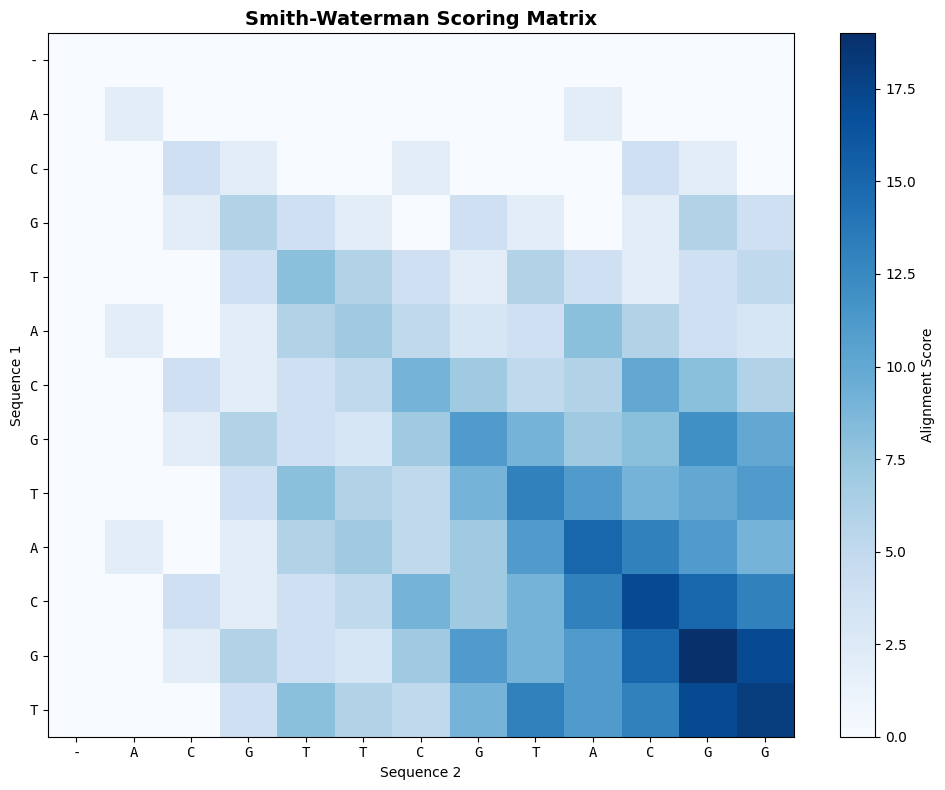

In [4]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
import matplotlib.pyplot as plt
import numpy as np
from src.smith_waterman import SmithWaterman

# Example: Compare two 16S rRNA fragments
seq1 = "ACGTACGTACGT"
seq2 = "ACGTTCGTACGG"

sw = SmithWaterman()

# Rebuild matrix for visualization
m, n = len(seq1), len(seq2)
H = np.zeros((m+1, n+1))
for i in range(1, m+1):
    for j in range(1, n+1):
        H[i][j] = max(0,
            H[i-1][j-1] + sw.score(seq1[i-1], seq2[j-1]),
            H[i-1][j] + sw.gap_open,
            H[i][j-1] + sw.gap_open)

plt.figure(figsize=(10, 8))
plt.imshow(H, cmap='Blues', aspect='auto')
plt.colorbar(label='Alignment Score')
plt.xticks(range(n+1), ['-'] + list(seq2), fontfamily='monospace')
plt.yticks(range(m+1), ['-'] + list(seq1), fontfamily='monospace')
plt.title('Smith-Waterman Scoring Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Sequence 2'); plt.ylabel('Sequence 1')
plt.tight_layout()
plt.savefig('results/sw_matrix.png', dpi=150)
plt.show()
